In [7]:
import logging

import numpy as np

from pomaar.array_synthesizer import ArraySynthesizer, interleave_linear_arrays

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

### Texas Instruments, AWRx cascaded radar RF evaluation module (MMWCAS-RF-EVM)
**Array structure:** The system is a 12x16 layout of series-fed patch antennas, built upon a 4-chip cascaded architecture. The receive array is divided into 3 sub-arrays (8+4+4), each containing active elements with a parasitic element on each side to facilitate more uniform embedded pattern via periodic repetition. The transmit array is an undivided 12-element array with mild non-uniformity in elevation.

**MIMO topology:**
- The 3 receive ULAs in azimuth are separated by λ/2.
- The transmitter array consists of a 9-element ULA with 2λ spacing in azimuth with an embedded 4-element minimum redundancy array (MRA) in elevation.

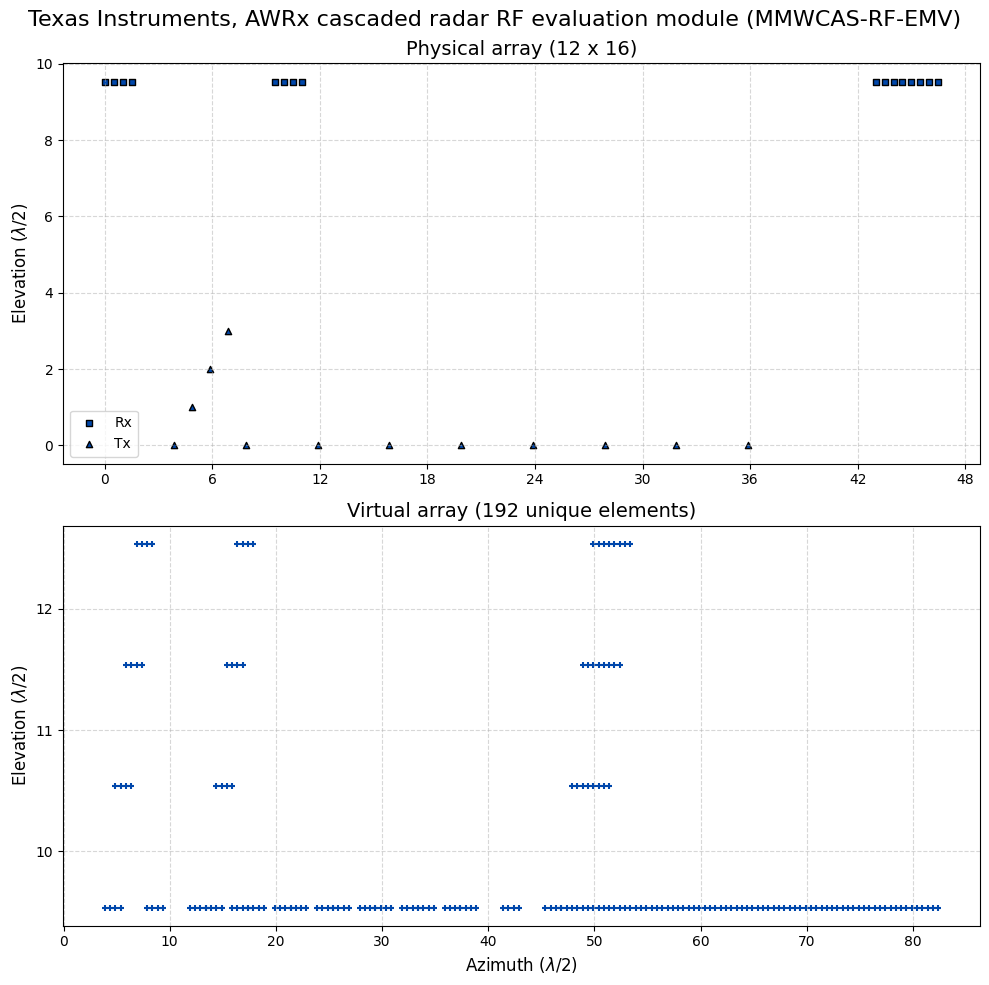

In [8]:
rx_ula = np.arange(0, 4 * 0.5, 0.5)
rx_b = np.column_stack((rx_ula, np.zeros_like(rx_ula)))
rx_c = rx_b[-1] + [8, 0] + rx_b
rx_ula = np.arange(0, 8 * 0.5, 0.5)
rx_a = rx_c[-1] + [32, 0] + np.column_stack((rx_ula, np.zeros_like(rx_ula)))
rx = [0, 19.072 / 2] + np.vstack((rx_a, rx_b, rx_c))

tx_ula = np.arange(0, 9 * 4, 4)
tx_azimuth = np.column_stack((tx_ula, np.zeros_like(tx_ula)))
tx_mra = np.column_stack((np.arange(1, 4 * 1, 1), [1, 2, 3]))
tx = [7.759 / 2, 0] + np.vstack((tx_azimuth[:3], tx_mra, tx_azimuth[3:]))

mimo = ArraySynthesizer(
    name="Texas Instruments, AWRx cascaded radar RF evaluation module (MMWCAS-RF-EMV)", highlight_overlaps=False
)
mimo.set_arrays(tx, rx)
mimo.plot_topology(marker_size=20)

### Tinti et al., Fully polarimetric automotive radar: proof of concept (2024)
**Array structure:** The system features a 12x16 MIMO array with H- and V-polarized sectoral horn antennas with rectangular milled step tapering. The array is constructed such that the 12 transmitters are divided into six H-polarized elements and six V-polarized elements. Likewise, the 16 receivers are divided into eight H-polarized and eight V-polarized elements. This uniform arrangement, with proper spacing, results in 192 virtual elements, divided into four subarrays of 48 elements, one for each of the four possible polarization combinations.

**MIMO topology:** To facilitate unambiguous angular estimation, the target virtual array is synthesized to be uniform with half-wavelength element spacing. Specifically, this is achieved using the following strategy:
- Rx and Tx arrays are vertically displaced (by a distance of about 4λ) into two non-uniform linear arrays.
- The receiver array (positioned at the top) is split into two uniform linear arrays (ULAs) with inner spacing of λ, separated by 13λ.
- Transmitters (in the bottom row) are grouped in pairs, separated by 1.5λ, with inter-pair distance of 8λ.

INFO: 45 calibration overlaps found: (-22.0, 8.0), (-21.0, 8.0), (-20.0, 8.0), (-19.0, 8.0), (-18.0, 8.0), (-17.0, 8.0), (-16.0, 8.0), (-15.0, 8.0), (-14.0, 8.0), (-13.0, 8.0), (-12.0, 8.0), (-11.0, 8.0), (-10.0, 8.0), (-9.0, 8.0), (-8.0, 8.0), (-7.0, 8.0), (-6.0, 8.0), (-5.0, 8.0), (-4.0, 8.0), (-3.0, 8.0), (-2.0, 8.0), (-1.0, 8.0), (0.0, 8.0), (1.0, 8.0), (2.0, 8.0), (3.0, 8.0), (4.0, 8.0), (5.0, 8.0), (6.0, 8.0), (7.0, 8.0), (8.0, 8.0), (9.0, 8.0), (10.0, 8.0), (11.0, 8.0), (12.0, 8.0), (13.0, 8.0), (14.0, 8.0), (15.0, 8.0), (16.0, 8.0), (17.0, 8.0), (18.0, 8.0), (19.0, 8.0), (20.0, 8.0), (21.0, 8.0), (22.0, 8.0)


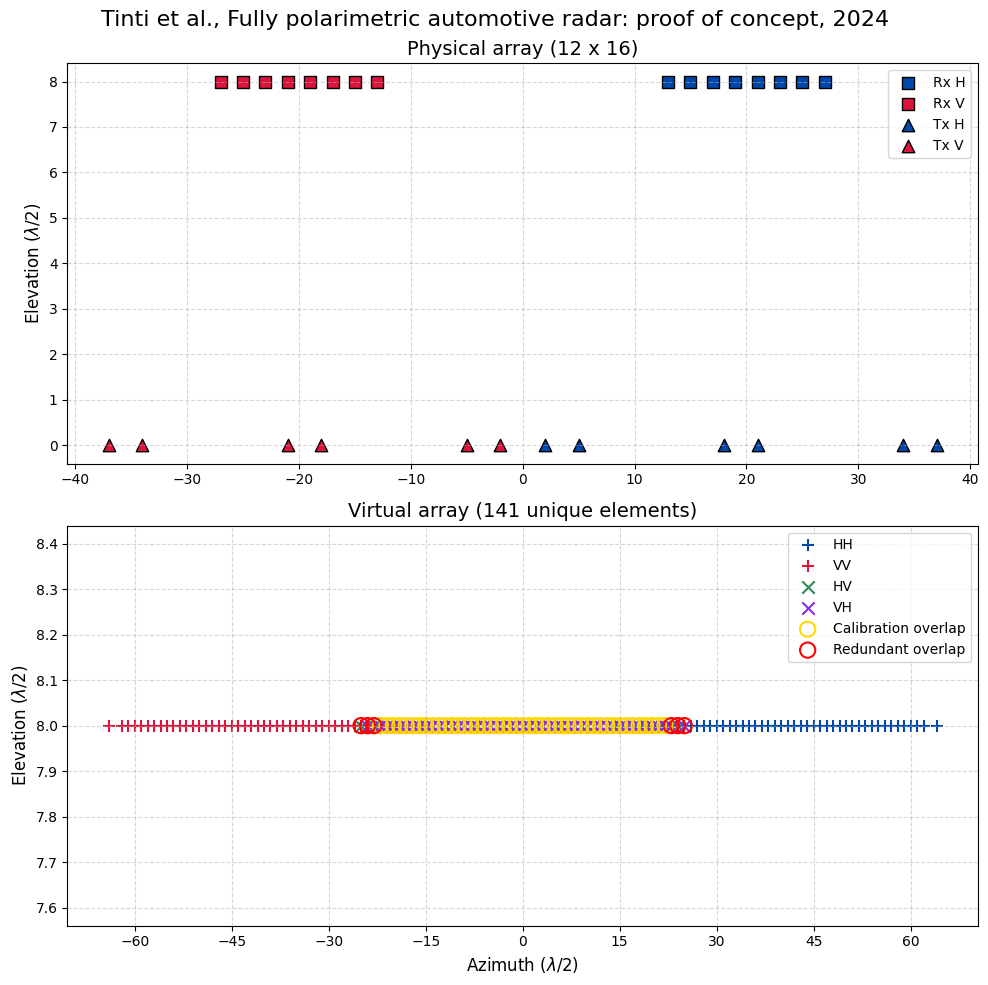

In [9]:
# Rx: Two eight-element ULAs, one for each polarization, with one-wavelength spacing
# Azimuth: sub-arrays displaced by 13 wavelengths apart
# Elevation: Rx array shifted up by about 4 wavelengths
spacing = 2
rx_ula = np.arange(0, 8 * spacing, spacing)
rx_ula = np.column_stack((rx_ula, np.zeros_like(rx_ula)))
rx_h = [13, 8] + rx_ula
rx_v = [-13, 8] - rx_ula

# Tx
tx_pair = np.array([[0, 0], [3, 0]])
offsets = np.array([[0, 0], [16, 0], [32, 0]])
tx_pairs = (offsets[:, None, :] + tx_pair[None, :, :]).reshape(-1, 2)
tx_h = [2, 0] + tx_pairs
tx_v = [-2, 0] - tx_pairs

mimo = ArraySynthesizer(
    name="Tinti et al., Fully polarimetric automotive radar: proof of concept, 2024", highlight_overlaps=True
)
mimo.set_arrays(tx_h=tx_h, rx_h=rx_h, tx_v=tx_v, rx_v=rx_v)
mimo.plot_topology()

### Rectangular 12x16 array

A simple array idea.

**Observations:**
- Impossible to obtain useful overlaps while maintaining a rectangular shape **without interleaving elements**.
- Embedded pattern will likely be heavily influenced by coupling, especially in the corners of neighbouring transmitters and receivers. 

No overlaps found.


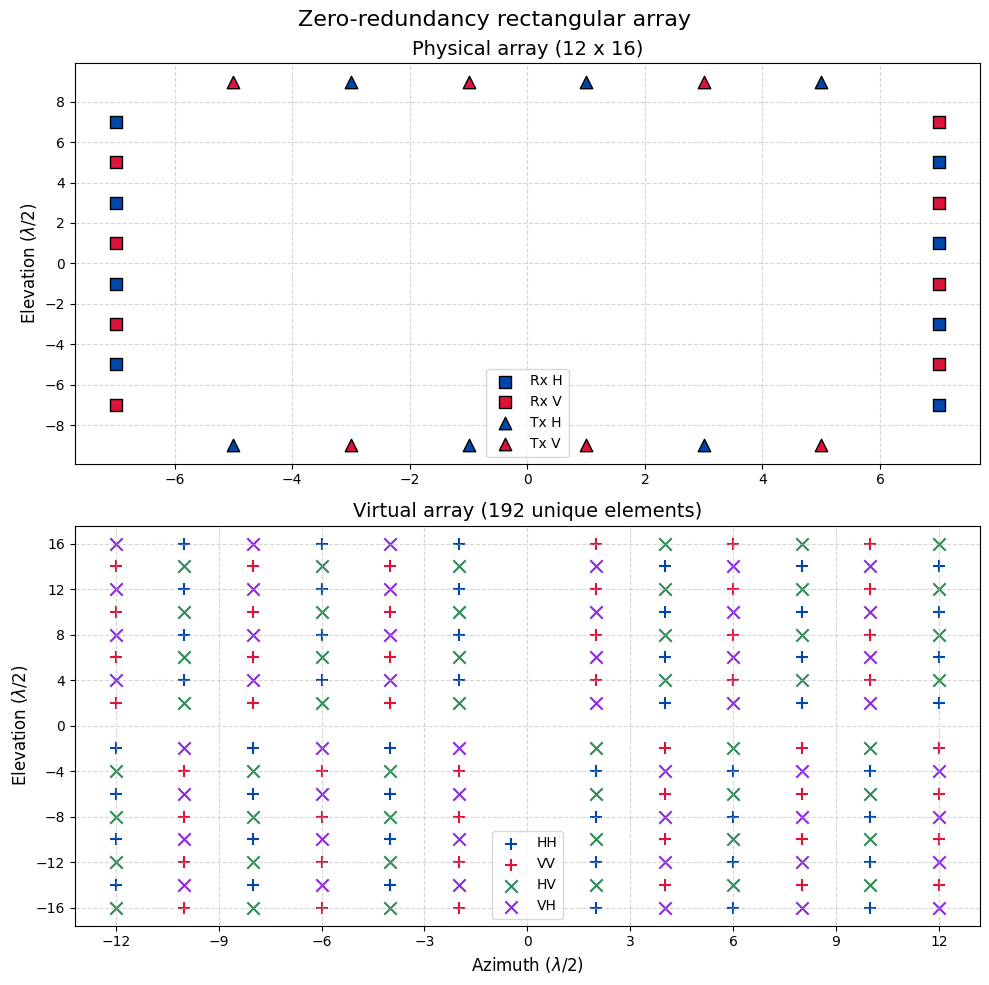

In [10]:
interleave = True
offset = 2
spacing = 2

tx_ula = np.arange(0, 6 * spacing, spacing)
rx_ula = np.arange(0, 8 * spacing, spacing)
tx_h = np.column_stack((offset + tx_ula, np.zeros_like(tx_ula)))
rx_h = np.column_stack((2 * offset + spacing * (len(tx_ula) - 1) * np.ones_like(rx_ula), offset + rx_ula))
tx_v = np.column_stack((offset + tx_ula, 2 * offset + spacing * (len(rx_ula) - 1) * np.ones_like(tx_ula)))
rx_v = np.column_stack((np.zeros_like(rx_ula), offset + rx_ula))

if interleave:
    tx_h, tx_v = interleave_linear_arrays(tx_h, tx_v)
    rx_h, rx_v = interleave_linear_arrays(rx_h, rx_v)

mimo = ArraySynthesizer(name="Zero-redundancy rectangular array")
mimo.set_arrays(tx_h=tx_h, rx_h=rx_h, tx_v=tx_v, rx_v=rx_v, centre=True)
mimo.plot_topology()


### Rectangular 12x16 array

The same simple array idea, now with filled corners.

No overlaps found.


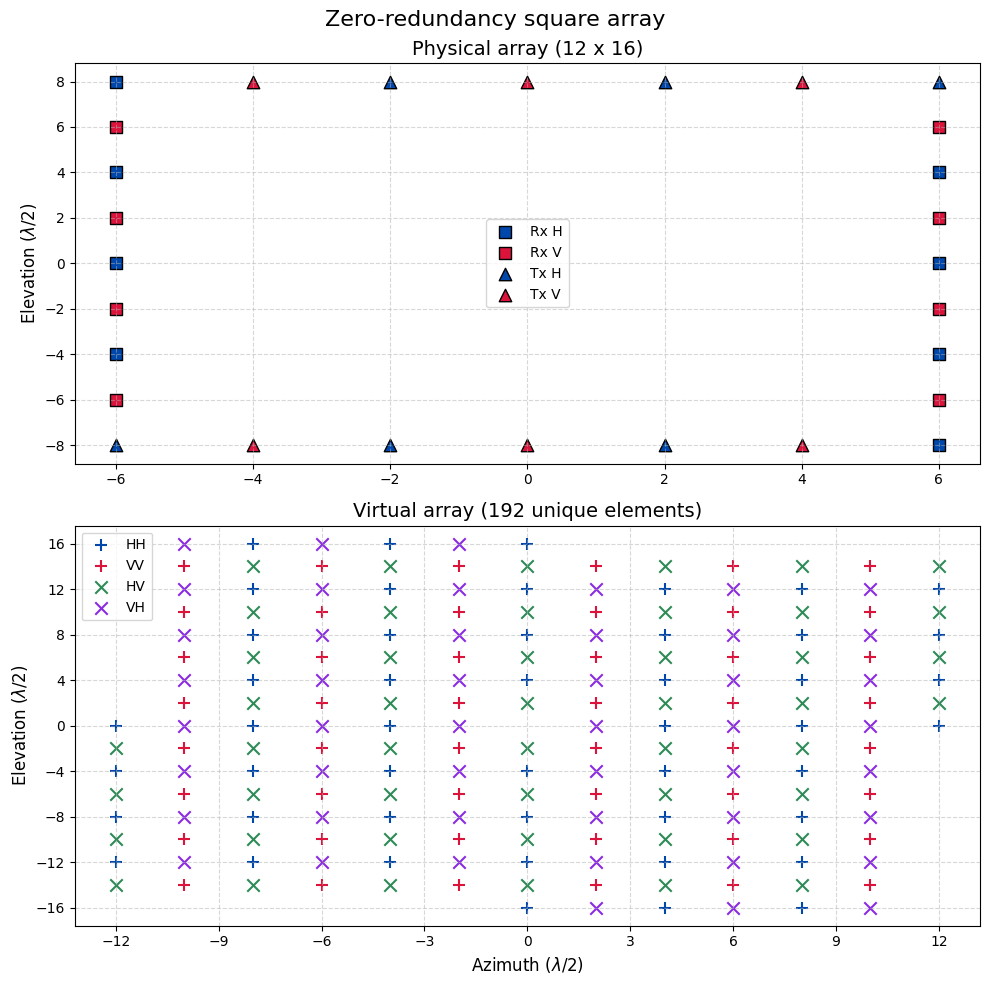

In [11]:
interleave = True
spacing = 2
tx_ula = np.arange(0, 6 * spacing, spacing)
rx_ula = np.arange(0, 8 * spacing, spacing)

tx_h = np.column_stack((tx_ula, np.zeros_like(tx_ula)))
rx_h = np.column_stack((spacing * len(tx_ula) * np.ones_like(rx_ula), rx_ula))
tx_v = np.column_stack((tx_ula + spacing, spacing * len(rx_ula) * np.ones_like(tx_ula)))
rx_v = np.column_stack((np.zeros_like(rx_ula), rx_ula + spacing))

if interleave:
    tx_h, tx_v = interleave_linear_arrays(tx_h, tx_v)
    rx_h, rx_v = interleave_linear_arrays(rx_h, rx_v)

mimo = ArraySynthesizer(name="Zero-redundancy square array")
mimo.set_arrays(tx_h=tx_h, rx_h=rx_h, tx_v=tx_v, rx_v=rx_v, centre=True)
mimo.plot_topology()


### Custom design \#2

This array is constructed by first setting the target virtual array and subsequently working back to obtain the physical element positions.